# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Важно
- Заполняйте все ячейки с пометкой `# YOUR CODE HERE`.
- Не удаляйте проверки: они подскажут, правильно ли вы идёте.
- Вопросы для размышления помогут вам глубже понять алгоритм.

## Датасеты
- **`make_moons`** и **`make_circles`** из `sklearn.datasets`: 2D-данные с нелинейными кластерами.
- **Wine** (`load_wine`): реальный многомерный датасет (13 признаков, 3 класса).

## Что сдавать
1. Заполненный ноутбук со всеми графиками.
2. Краткие выводы в конце каждого раздела.
3. Итоговый вывод: когда DBSCAN лучше K-Means и когда нет.

## Краткая теория

### Типы точек в DBSCAN

DBSCAN задаётся двумя параметрами: радиусом окрестности `eps` (ε) и минимальным числом точек `min_samples`.

- **Корневая точка** (core): в её ε-окрестности ≥ `min_samples` точек.
- **Граничная точка** (border): в её ε-окрестности < `min_samples`, но она достижима из корневой.
- **Шумовая точка** (noise): не является ни корневой, ни граничной → метка **-1**.

### Как работает алгоритм

1. Для каждой непосещённой точки найти её ε-окрестность.
2. Если точек ≥ `min_samples` — начать новый кластер.
3. Рекурсивно расширить кластер через цепочки плотно достижимых точек.
4. Оставшиеся точки → шум (метка -1).

### Как выбрать eps: k-distance plot

Для каждой точки вычисляют расстояние до её k-го ближайшего соседа (k = `min_samples`). Отсортированный по убыванию график этих расстояний называется **k-distance plot**. Резкий перегиб («локоть») указывает на оптимальное значение `eps`.

---
## Шаг 1. Импорты и настройки

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Импорты выполнены успешно!")

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

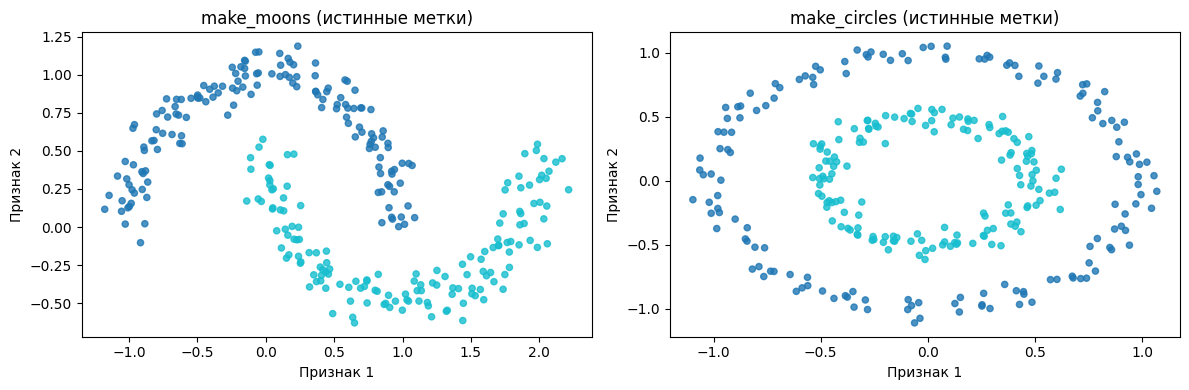

In [2]:
# Генерация датасетов
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=y_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

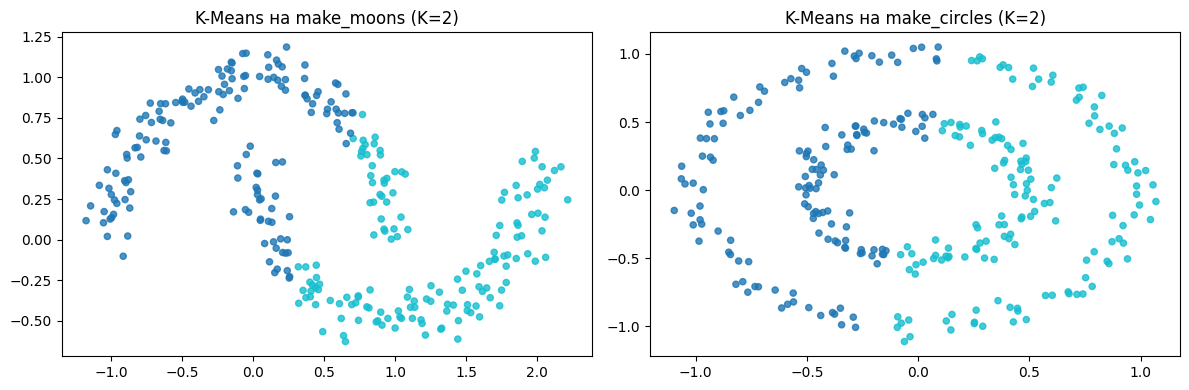

In [3]:
# Применим K-Means к этим датасетам
# YOUR CODE HERE
# 1. Создайте KMeans с n_clusters=2, random_state=RANDOM_STATE
# 2. Обучите на X_moons и X_circles
# 3. Получите метки кластеров
kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE)  # замените None
labels_km_moons = kmeans_moons.fit_predict(X_moons)

kmeans_circles = KMeans(n_clusters=2, random_state = RANDOM_STATE)
labels_km_circles = kmeans_circles.fit_predict(X_circles)

# Визуализация результатов K-Means
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** Почему K-Means не может правильно разделить «луны» и «кольца»? Связано ли это с формой функционала ошибки?

Потому что KMeans предполагает выпуклость формы кластеров. Да связано потому что алгоритм мимнимизирует квадрат расстояний точек кластера до центроиды. потому те точки что расположены на одном из концов кластера луны оказываются не в своих кластерах т.к. они геометрически расположены ближе к центроиде второго кластера.

---
## Шаг 3. k-Distance Plot и выбор eps

Построим k-distance plot для датасета `make_moons`. Используем k = 5 (= `min_samples`).

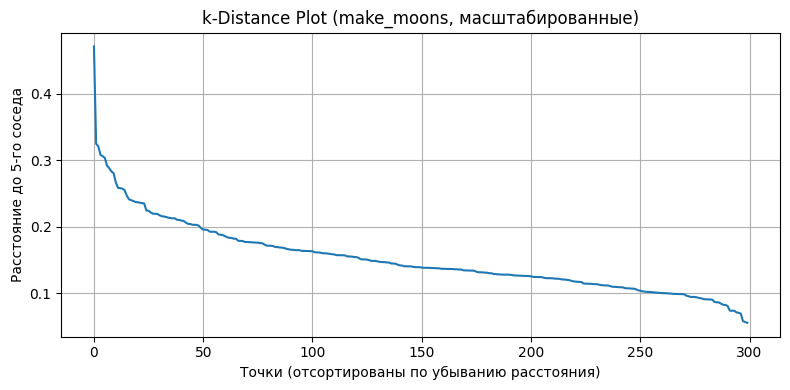

Найдите 'локоть' на графике и запишите подходящее значение eps:


In [4]:
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)
k = 5

# YOUR CODE HERE
# 1. Создайте NearestNeighbors(n_neighbors=k) и обучите на X_moons_scaled
# 2. Вызовите .kneighbors() для получения матрицы расстояний
# 3. Возьмите расстояние до k-го соседа (последний столбец distances)
# 4. Отсортируйте по убыванию
knn_model = NearestNeighbors(n_neighbors=k)
knn_model.fit(X_moons_scaled)
distances, indices = knn_model.kneighbors(X_moons_scaled)
k_distances_moons = np.sort(distances[:, -1])[::-1] # замените

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps:")

**❓ Вопрос для размышления:** Где находится «локоть»? Как он указывает на границу между точками кластеров и шумом?

Локоть на этом графике находится примерно в районе 0.25-0.28
Слева от локтя расстояние до 5го соседа должно резко возрастать то бишь там шум. Справа от локтя график должен выходить на плато что говорит о принадлежности к некоторому кластеру точек справа

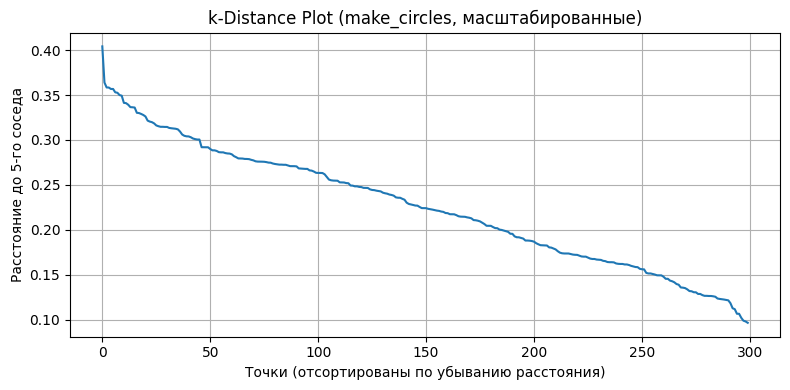

In [5]:

scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

knn_model_circles = NearestNeighbors(n_neighbors=7)
knn_model_circles.fit(X_circles_scaled)
circles_distances, circles_indices = knn_model_circles.kneighbors(X_circles_scaled)
k_distances_circles = np.sort(circles_distances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_circles)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_circles, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

Здесь же для circles локоть находится в районе 0.34 при min_samples = 7

---
## Шаг 4. DBSCAN на нелинейных датасетах

Применим DBSCAN к `make_moons` и `make_circles`. Обратите внимание на масштабирование.

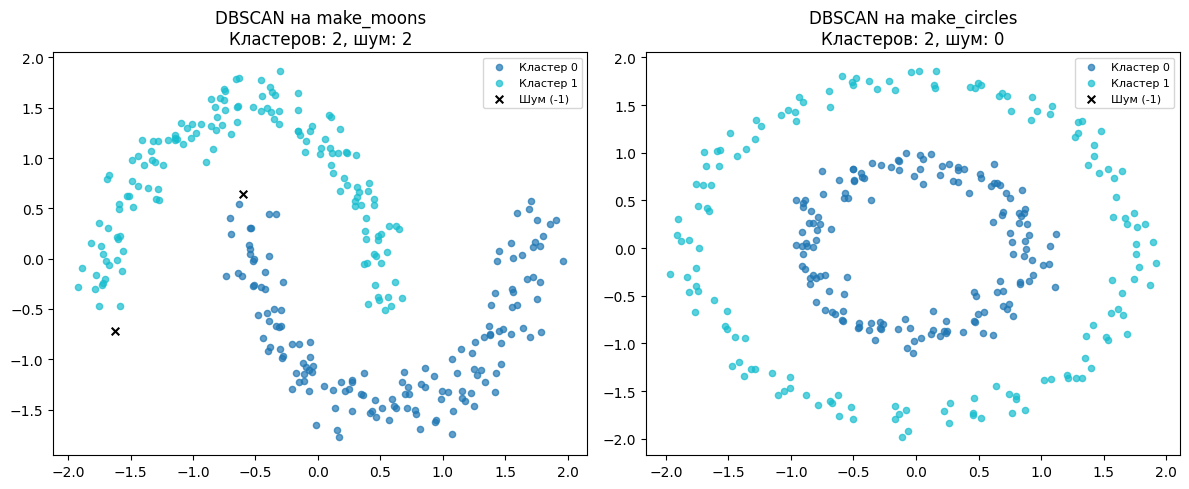

In [6]:



# YOUR CODE HERE
# 1. Создайте DBSCAN с подобранным eps (из k-distance plot) и min_samples=5
# 2. Примените fit_predict к X_moons_scaled и X_circles_scaled
# 3. Подберите параметры так, чтобы алгоритм нашёл 2 кластера

db_moons = DBSCAN(eps=0.25, min_samples=5)   # замените
labels_db_moons = db_moons.fit_predict(X_moons_scaled)

db_circles = DBSCAN(eps=0.34, min_samples=7)
labels_db_circles = db_circles.fit_predict(X_circles_scaled)

# Вспомогательная функция для визуализации
def plot_dbscan_results(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    noise_mask = labels == -1
    colors = cm.tab10(np.linspace(0, 1, max(labels)+1)) if max(labels) >= 0 else []

    for i in range(max(labels)+1):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[i], label=f'Кластер {i}')

    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s=30, c='black', marker='x', label='Шум (-1)')

    n_cl = max(labels) + 1 if max(labels) >= 0 else 0
    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_cl}, шум: {n_noise}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, "DBSCAN на make_moons", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, "DBSCAN на make_circles", axes[1])
plt.tight_layout()
plt.show()

---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

In [7]:
# Сравнение силуэта DBSCAN vs K-Means для make_moons

# YOUR CODE HERE
# 1. Обучите KMeans(n_clusters=2) на X_moons_scaled
# 2. Вычислите silhouette_score для K-Means
# 3. Вычислите silhouette_score для DBSCAN (только для некластерных точек!)
#    Подсказка: исключите точки с labels == -1
kmeans_2 = KMeans(n_clusters=2, random_state = RANDOM_STATE)
labels_kmeans_2 = kmeans_2.fit_predict(X_moons_scaled)
score_kmeans = silhouette_score(X_moons_scaled, labels_kmeans_2)

dbscan_no_noise = labels_db_moons != -1
score_dbscan = silhouette_score(X_moons_scaled[dbscan_no_noise], labels_db_moons[dbscan_no_noise])

print("=== Коэффициент силуэта на make_moons ===")
print(f"K-Means (K=2): {score_kmeans:.3f}" if score_kmeans is not None else "K-Means: не вычислен")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: не вычислен")

=== Коэффициент силуэта на make_moons ===
K-Means (K=2): 0.494
DBSCAN:        0.387


**❓ Вопрос для размышления:** Какой алгоритм получил лучший силуэт? Соответствует ли это визуальному впечатлению? Можно ли всегда доверять силуэту как абсолютной мере качества?

K-Means получил лучший силуэт. Не соответствует визуальному впечатлению абсолютно, DBSCAN делает это лучше. На основе такого эксперимента можно сказать что однозначно доверять силуэту нельзя. Силуэт заточен на кластеры сферической выпуклой формы.

---
## Шаг 6. Исследование влияния гиперпараметров

Посмотрим, как меняется результат DBSCAN при разных значениях `eps` и `min_samples`.

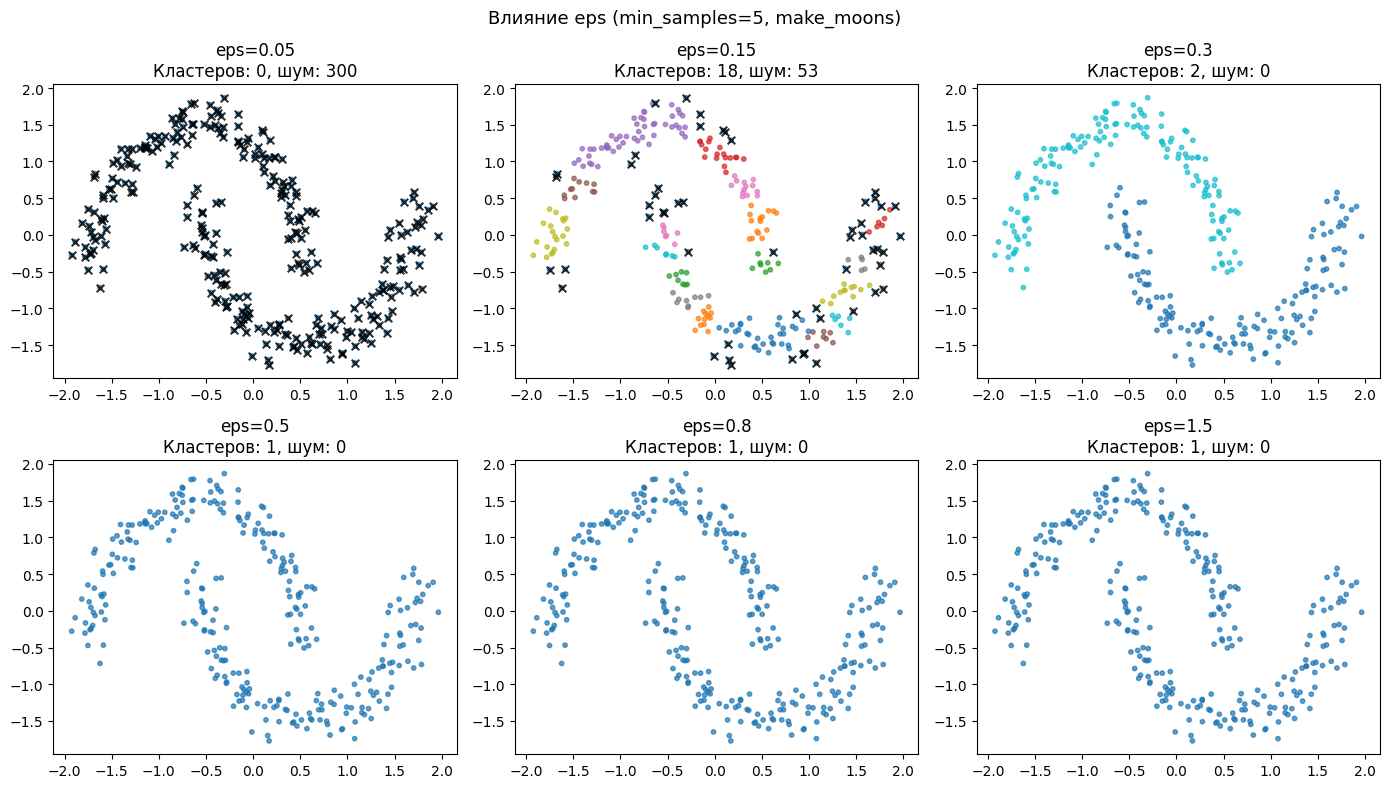

In [8]:
# Сетка eps при фиксированном min_samples=5
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    # YOUR CODE HERE
    # 1. Запустите DBSCAN(eps=eps_val, min_samples=5) на X_moons_scaled
    # 2. Получите метки
    # 3. Посчитайте число кластеров и шумовых точек
    # 4. Отобразите scatter plot с цветами по меткам
    #    Шумовые точки (label == -1) рисуйте чёрными крестиками
    dbscan_temp = DBSCAN(eps=eps_val, min_samples=5)
    labels_i = dbscan_temp.fit_predict(X_moons_scaled)  # замените

    if labels_i is not None:
        n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
        n_noise = (labels_i == -1).sum()
        mask_noise = labels_i == -1
        axes[i].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                        c=labels_i, cmap='tab10', s=10, alpha=0.7)

        # кресты поверх шумовых точек
        axes[i].scatter(X_moons_scaled[mask_noise, 0],
                        X_moons_scaled[mask_noise, 1],
                        s=30, c='black', marker='x', alpha=0.8)

        axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")
    else:
        axes[i].set_title(f"eps={eps_val} (не вычислено)")

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** При каком `eps` алгоритм нашёл два правильных кластера? Что происходит при слишком малом и слишком большом значении?

При eps равном 0.3 алгоритм правильно выделили 2 кластера без шума. Если eps слишком мал то происходит дробление кластеров и увеличивается количество шумовых точек. Если же eps слишком велик то кластеры начинают сливаться между собой.

---
## Шаг 7. DBSCAN на реальном датасете Wine

Теперь перейдём к реальным данным. Датасет Wine: 178 образцов вина из трёх сортов винограда, 13 химических признаков.

In [9]:
# Загрузка датасета Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  # истинные метки (не используем при кластеризации!)
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

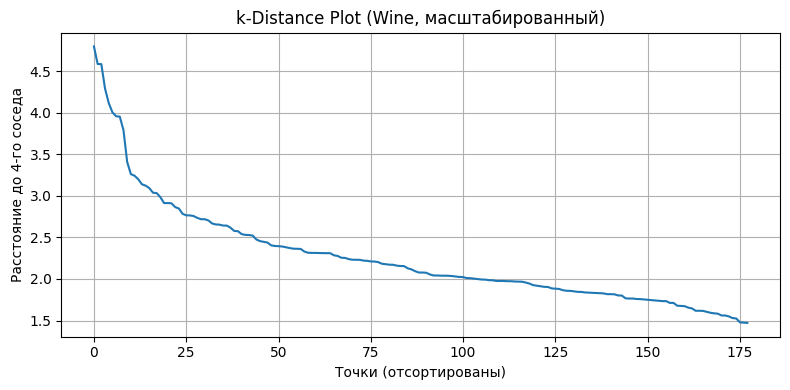

In [10]:
# YOUR CODE HERE
# 1. Масштабируйте X_wine с помощью StandardScaler
# 2. Постройте k-distance plot (k=4)
# 3. Визуально определите «локоть» и запишите подходящее eps
wine_scaler = StandardScaler()

X_wine_scaled = wine_scaler.fit_transform(X_wine)  # замените
k_wine = 4
knn_wine = NearestNeighbors(n_neighbors = k_wine)
knn_wine.fit(X_wine_scaled)
wine_distances, wine_indices = knn_wine.kneighbors(X_wine_scaled)
k_dist_wine = np.sort(wine_distances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
if k_dist_wine is not None:
    plt.plot(k_dist_wine)
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.grid(True)
plt.tight_layout()
plt.show()

По графиук мне показалось что чтото подхлдящее в районе 3.0-3.2, но эксперимент показал что это фатально неверно.

In [11]:
# YOUR CODE HERE
# 1. Запустите DBSCAN на X_wine_scaled с выбранным eps и min_samples=4
# 2. Выведите: число кластеров, число шумовых точек, долю шума
# 3. Если кластеров > 1, вычислите силуэт (исключив шум)

eps_wine = 2.1  # выбрал по графику

db_wine = DBSCAN(eps=eps_wine, min_samples=4)
labels_wine = db_wine.fit_predict(X_wine_scaled)

n_clusters_wine = len(set(labels_wine)) - (1 if -1 in labels_wine else 0)
n_noise_wine = (labels_wine == -1).sum()
noise_ratio = n_noise_wine / len(labels_wine) * 100

print("=== Результаты DBSCAN на Wine ===")
print(f"Выбранный eps: {eps_wine}")
print(f"Количество кластеров: {n_clusters_wine}")
print(f"Количество шумовых точек: {n_noise_wine}")
print(f"Доля шума: {noise_ratio:.2f}%")


if n_clusters_wine >= 2:
    labels_no_noise = labels_wine != -1
    if labels_no_noise.sum() >= 2:
        score_wine = silhouette_score(X_wine_scaled[labels_no_noise],
                                      labels_wine[labels_no_noise])
        print(f"\nСилуэт: {score_wine:.3f}")
    else:
        print("\nнехватило точек для вычисления")
else:
    print("\nсилуэт не вычислен (меньше 2 кластеров)")

=== Результаты DBSCAN на Wine ===
Выбранный eps: 2.1
Количество кластеров: 3
Количество шумовых точек: 57
Доля шума: 32.02%

Силуэт: 0.211


только при eps в районе 2.15 получается нахождение 3х кластеров. Иначе разброд и шатание. Опять таки смотря на силуэт мне не ясно что там происходит. 13 признаков - визуализировать не вариант.

кстати закидывал график в дипсик и гемини: каждый раз выдавали слегка разные положения локтя но в целом это был промежуток 2.8 - 3.3

---
## Шаг 8. Анализ шумовых точек

Шумовые точки — это объекты, которые DBSCAN не смог отнести ни к одному кластеру. В задаче кластеризации они могут нести важную информацию.

In [12]:
# YOUR CODE HERE
# 1. Выберите строки X_wine, соответствующие шумовым точкам (labels_wine == -1)
# 2. Создайте DataFrame с признаками шумовых точек
# 3. Сравните среднее значение признаков шумовых точек
#    со средним по всей выборке (df_wine.mean())
# 4. Какие признаки у шумовых точек сильно отличаются от среднего?

noise_mask_wine = labels_wine == -1   # маска для шумовых точек
X_wine_noise = X_wine[noise_mask_wine]      # признаки шумовых точек

print("=== Средние значения признаков ===")
# ваш код
df_wine = pd.DataFrame(X_wine, columns=feature_names)
df_noise = pd.DataFrame(X_wine_noise, columns=feature_names)

comparison_df = pd.DataFrame({
    'Mean': df_wine.mean(),
    'Mean noise': df_noise.mean(),
    'diff %': (df_noise.mean() - df_wine.mean()) / df_wine.mean() * 100
})
print(comparison_df.round(2))

=== Средние значения признаков ===
                                Mean  Mean noise  diff %
alcohol                        13.00       12.74   -2.01
malic_acid                      2.34        2.55    8.96
ash                             2.37        2.35   -0.56
alcalinity_of_ash              19.49       20.09    3.05
magnesium                      99.74      101.11    1.37
total_phenols                   2.30        2.34    1.99
flavanoids                      2.03        2.02   -0.57
nonflavanoid_phenols            0.36        0.37    2.93
proanthocyanins                 1.59        1.71    7.73
color_intensity                 5.06        4.45  -12.07
hue                             0.96        0.97    1.76
od280/od315_of_diluted_wines    2.61        2.54   -2.74
proline                       746.89      645.35  -13.60


наиболее отличаются proline, color_intensity, proanthocyanins, malic_acid

**❓ Вопрос для размышления:** Чем отличаются шумовые точки от остальных? Являются ли они «плохими» данными или это реальные аномалии?

Шумовые точки отличаются нестандартными или экстремальными значениями каких либо признаков. Вероятно это просто редкие сорты вина с нестандартными характеристиками.

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

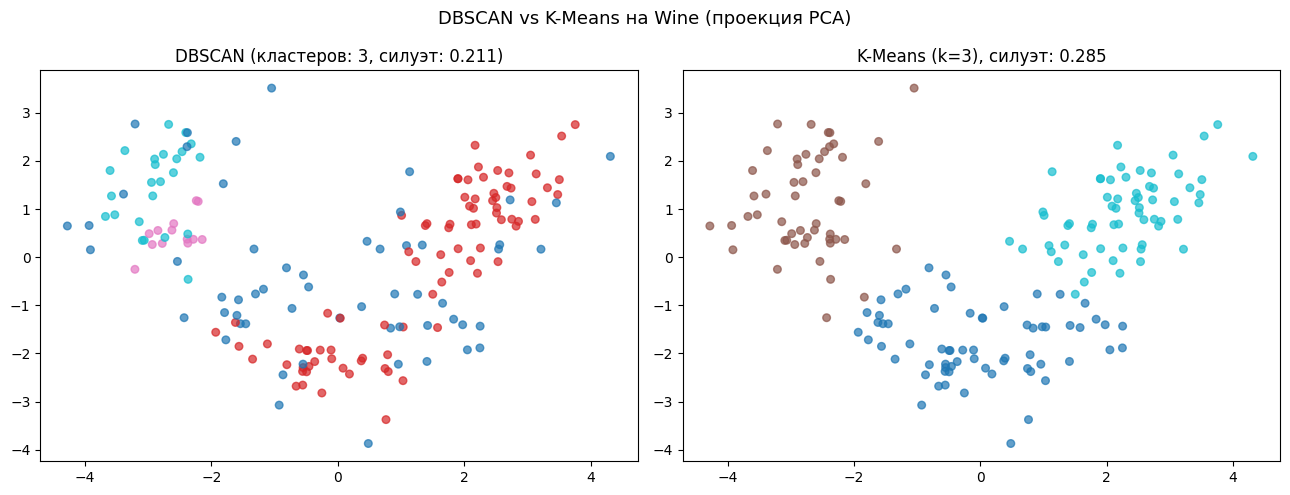

In [13]:
# YOUR CODE HERE
# 1. Обучите KMeans с числом кластеров = числу кластеров DBSCAN
#    (или с n_clusters=3, так как истинных классов 3)
# 2. Вычислите силуэт для K-Means
# 3. Сравните силуэт DBSCAN и K-Means
# 4. Визуализируйте результаты обоих методов в 2D (первые два признака
#    после масштабирования или используйте PCA до 2 компонент)

# Подсказка для PCA:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# DBSCAN
# ваш код
axes[0].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1],
                c=labels_wine, cmap='tab10', s=30, alpha=0.7)
axes[0].set_title(f"DBSCAN (кластеров: {n_clusters_wine}, силуэт: {score_wine:.3f})")

# K-Means
# ваш код
kmeans_wine_final = KMeans(n_clusters=n_clusters_wine, random_state=RANDOM_STATE)
labels_kmeans_final = kmeans_wine_final.fit_predict(X_wine_scaled)
score_kmeans_final = silhouette_score(X_wine_scaled, labels_kmeans_final)

axes[1].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1],
                c=labels_kmeans_final, cmap='tab10', s=30, alpha=0.7)
axes[1].set_title(f"K-Means (k={n_clusters_wine}), силуэт: {score_kmeans_final:.3f}")

plt.suptitle("DBSCAN vs K-Means на Wine (проекция PCA)", fontsize=13)
plt.tight_layout()
plt.show()

силуэт в обоих случаях плохой. Но слева визуально тотальный коллапс

---
## Шаг 10. Итоговые выводы

Ответьте на следующие вопросы в ячейке ниже (текст Markdown):

**1. Когда DBSCAN выигрывает у K-Means?**

> DBSCAN выйгрывает когда кластеры имею сложную форму. Или имеется шум который не нужно никуда относить. Кроме того DBSCAN не требует знания количества кластеров.

**2. Когда K-Means предпочтительнее?**

> Когда кластеры имеют вырадженную выпуклую сферическую форму и примерно одинаковую плотность.

**3. Почему масштабирование обязательно для DBSCAN?**

> Потому что если не скейлить то признки с большими числами будут доминировать и ролять при подсчете евклидова расстояния.

**4. Как интерпретировать шумовые точки в датасете Wine?**

> Шумовые точки это образцы с экстремальными значениями признаков. Возможно это редкие сорта вина или образцы с необычным химическим составом.

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

> Нет. Силуэт хорошо смотреть для кластеров имеющих выпуклую сферическую форму. У лун силуэт будет плохой но DBSCAN как экспериментально визуально было проверно справляется хорошо.